In [1]:
import jax
import numpy as np
from aim_resolve import SignalModel, PointModel, TileModel, ComponentModel, plot_arrays

key = jax.random.PRNGKey(123)

jwst not installed. Some JWST functions will not work.
shapely not installed. Some JWST functions will not work.


/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Vector(
	{'bg alpha asperity': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 'bg alpha flexibility': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 'bg alpha fluctuations': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 'bg alpha loglogavgslope': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 'bg alpha mean': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 'bg alpha spectrum': ShapeWithDtype(shape=(133, 2), dtype=<class 'numpy.float64'>),
	 'bg alpha xi': ShapeWithDtype(shape=(32, 32), dtype=<class 'numpy.float64'>),
	 'bg dev sigma': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 'bg dev xi': ShapeWithDtype(shape=(2, 32, 32), dtype=<class 'numpy.float64'>),
	 'bg i0 asperity': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 'bg i0 flexibility': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 'bg i0 fluctuations': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 'bg i0 loglogavgslope

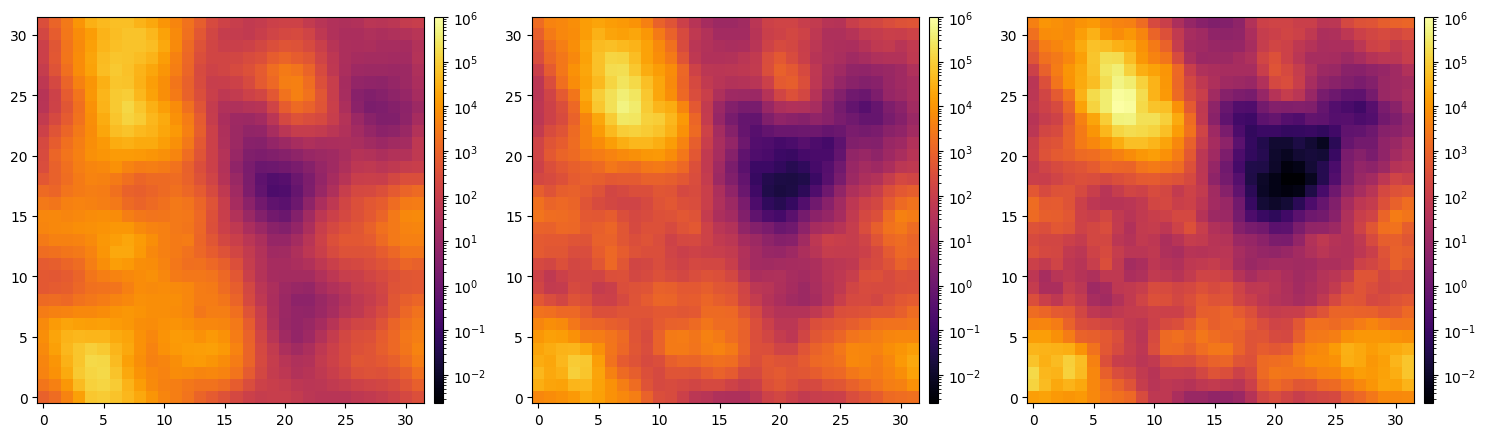

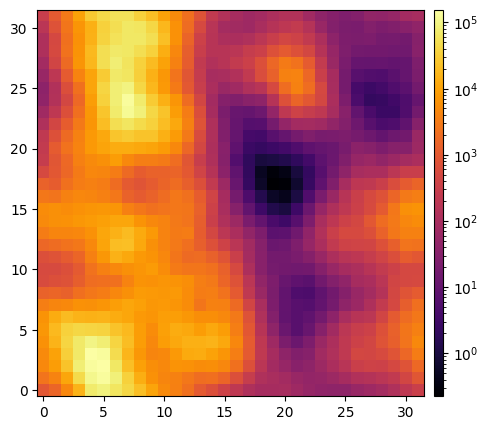

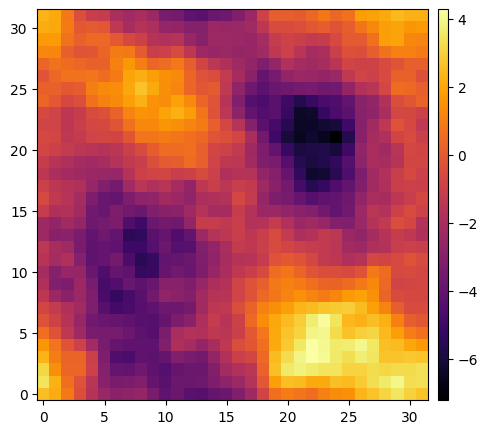

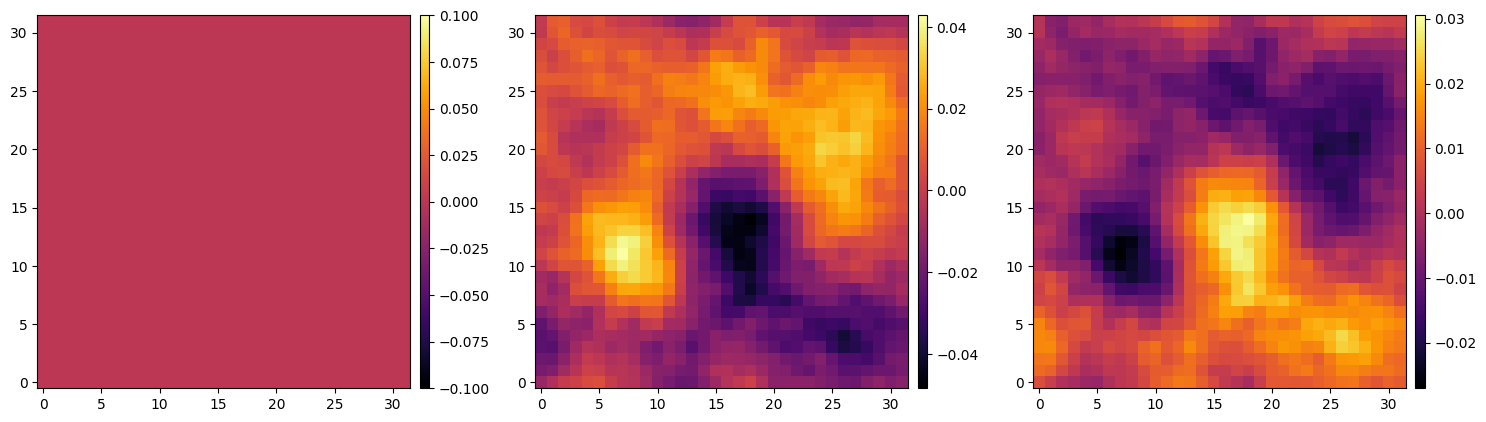

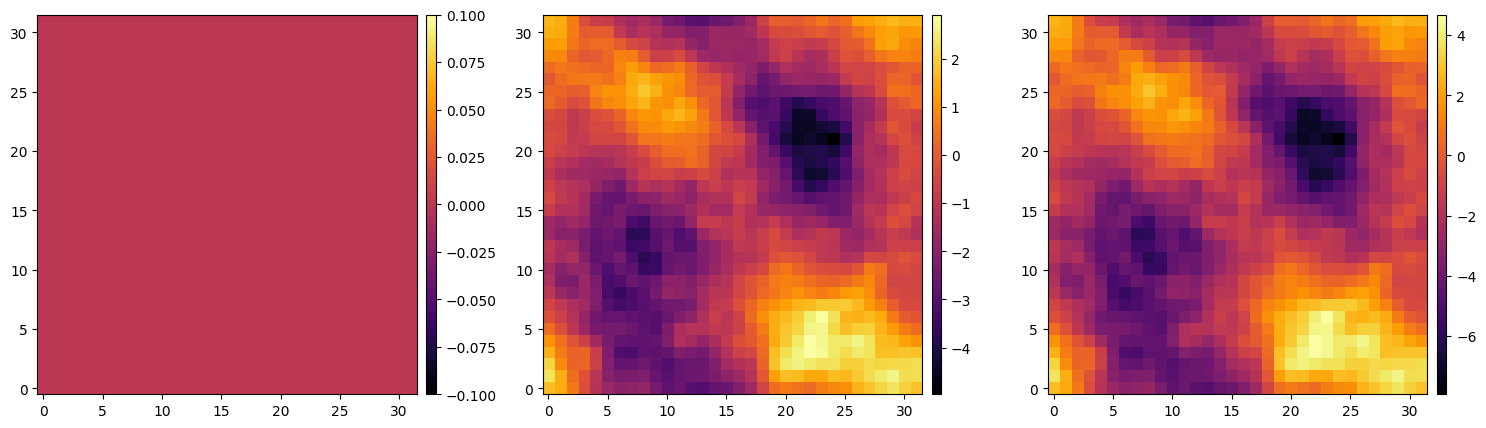

In [2]:
bg = SignalModel.build(
    prefix='bg',
    grid=dict(space=(32, 32), fov=('2deg', '2deg')),
    freq=np.array([1e9, 2e9, 3e9]),
    offset = 5,
    params=dict(
        ref_freq_index = 0,
        zero_mode=[3, 1],
        spatial_amplitude=dict(
            fluctuations=[5, 1],
            loglogavgslope=[-2, 0.5],
            flexibility=[1.2, 0.4],
            asperity=[0.2, 0.2],
        ),
        spectral_index=dict(
            mean=[-1, 0.5],
            fluctuations=[3, 1],
        ),
        spectral_amplitude=dict(
            loglogavgslope=[-2, 0.5],
            flexibility=[1.2, 0.4],
            asperity=[0.2, 0.2],
        ),
        deviations=dict(
            process='wiener',
            sigma=[0.2, 0.08],
        ),
    ),
)
print(bg.domain)

key, subkey = jax.random.split(key)
xi = bg.init(subkey)
res = bg(xi)
print(res.shape)

plot_arrays(res, norm='log', rows=1, vmin=res.min(), vmax=res.max())

plot_arrays(bg.ref_freq_model(xi), rows=1, norm='log')
plot_arrays(bg.spectral_index(xi), rows=1)
plot_arrays(bg.spectral_deviations(xi), rows=1)
plot_arrays(bg.spectral_model(xi), rows=1)

Vector(
	{'oj alpha asperity': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 'oj alpha flexibility': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 'oj alpha fluctuations': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 'oj alpha loglogavgslope': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 'oj alpha mean': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 'oj alpha spectrum': ShapeWithDtype(shape=(40, 2), dtype=<class 'numpy.float64'>),
	 'oj alpha xi': ShapeWithDtype(shape=(16, 16), dtype=<class 'numpy.float64'>),
	 'oj dev sigma': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 'oj dev xi': ShapeWithDtype(shape=(2, 16, 16), dtype=<class 'numpy.float64'>),
	 'oj i0 asperity': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 'oj i0 flexibility': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 'oj i0 fluctuations': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
	 'oj i0 loglogavgslope'

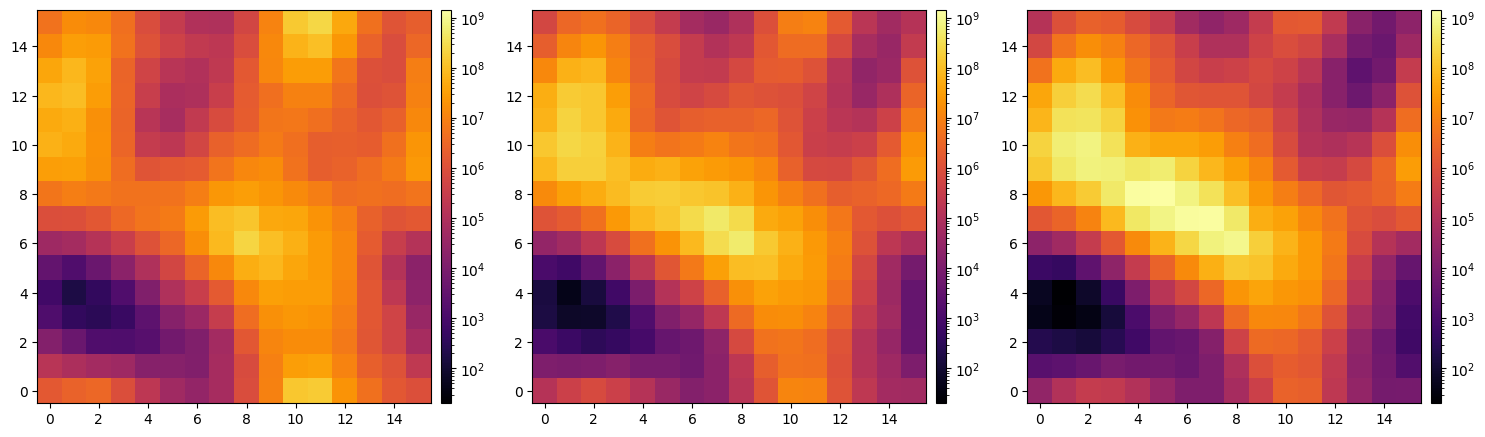

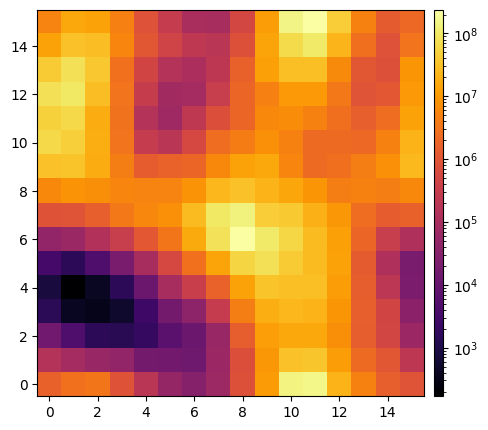

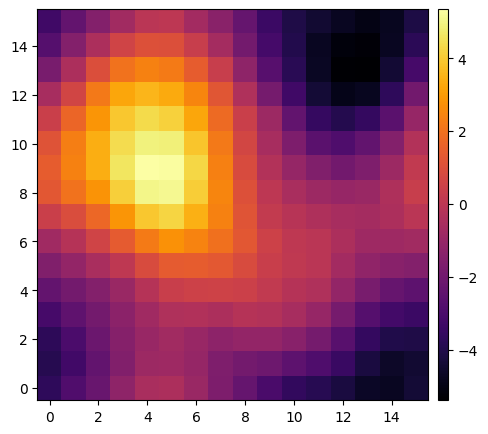

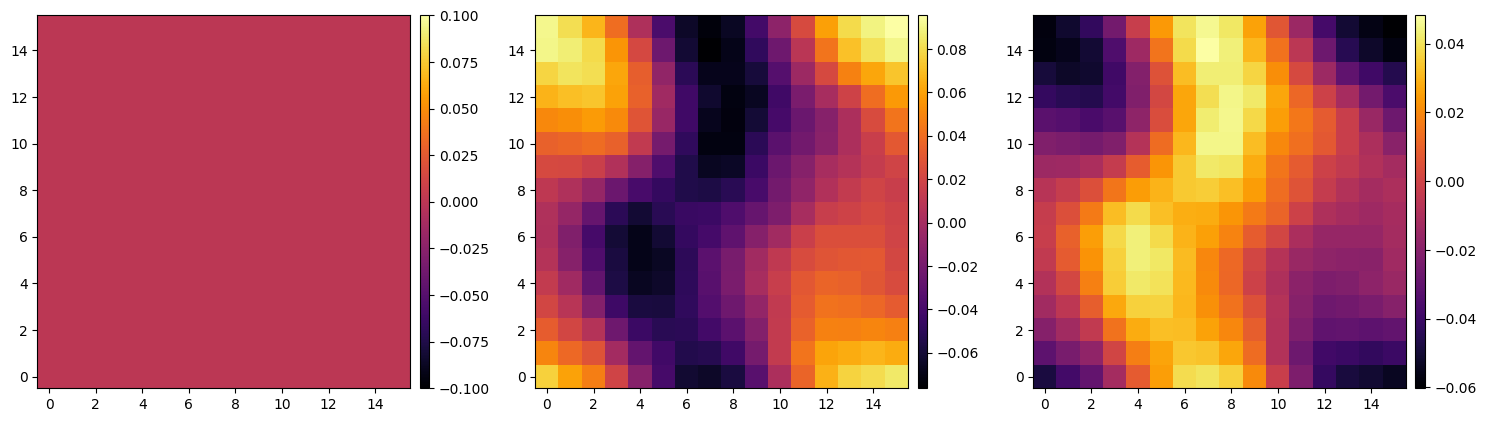

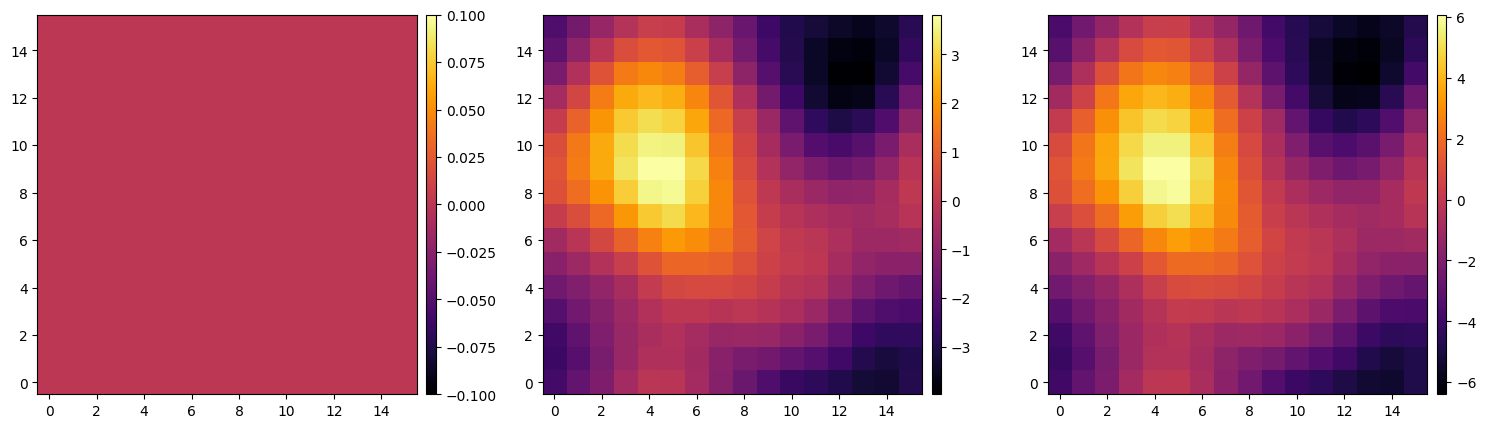

In [3]:
oj = SignalModel.build(
    prefix='oj',
    grid=dict(space=(8, 8), center=(0,0), factor=2),
    freq=np.array([1e9, 2e9, 3e9]),
    offset=10,
    params=dict(
        ref_freq_index = 0,
        zero_mode=[3, 1],
        spatial_amplitude=dict(
            fluctuations=[5, 1],
            loglogavgslope=[-2, 0.5],
            flexibility=[1.2, 0.4],
            asperity=[0.2, 0.2],
        ),
        spectral_index=dict(
            mean=[-1, 0.5],
            fluctuations=[3, 1],
        ),
        spectral_amplitude=dict(
            loglogavgslope=[-2, 0.5],
            flexibility=[1.2, 0.4],
            asperity=[0.2, 0.2],
        ),
        deviations=dict(
            process='wiener',
            sigma=[0.2, 0.08],
        ),
    ),
)
print(oj.domain)

key, subkey = jax.random.split(key)
xi = oj.init(subkey)
res = oj(xi)
print(res.shape)

plot_arrays(res, norm='log', rows=1, vmin=res.min(), vmax=res.max())

plot_arrays(oj.ref_freq_model(xi), rows=1, norm='log')
plot_arrays(oj.spectral_index(xi), rows=1)
plot_arrays(oj.spectral_deviations(xi), rows=1)
plot_arrays(oj.spectral_model(xi), rows=1)

Vector(
	{'pm alpha ': ShapeDtypeStruct(shape=(2, 1, 1), dtype=float64),
	 'pm dev sigma': ShapeDtypeStruct(shape=(2,), dtype=float64),
	 'pm dev xi': ShapeDtypeStruct(shape=(2, 2, 1, 1), dtype=float64),
	 'pm i0 ': ShapeDtypeStruct(shape=(2, 1, 1), dtype=float64)}
)


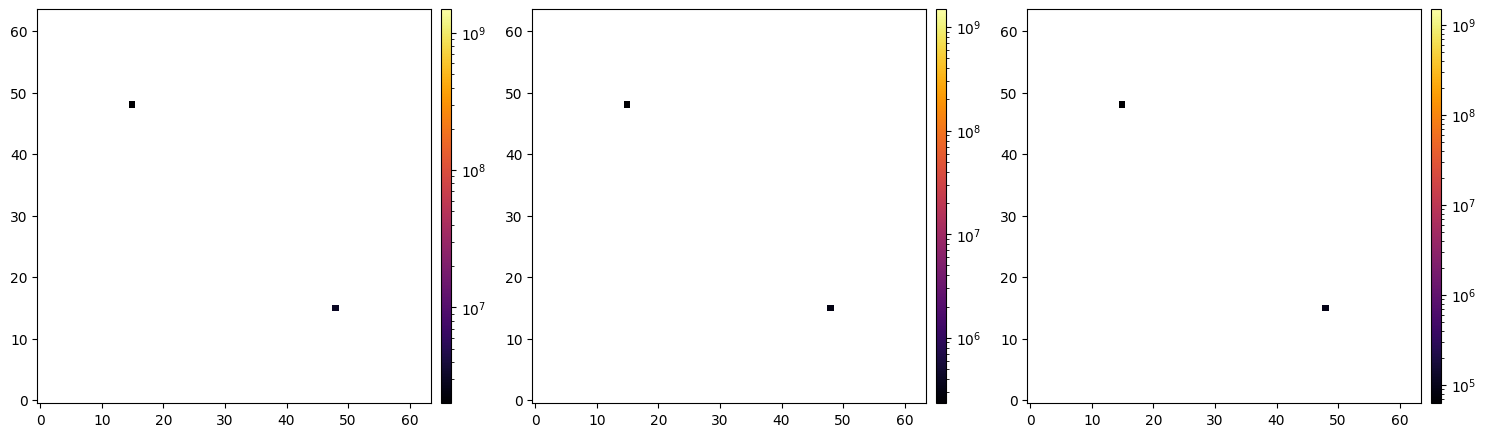

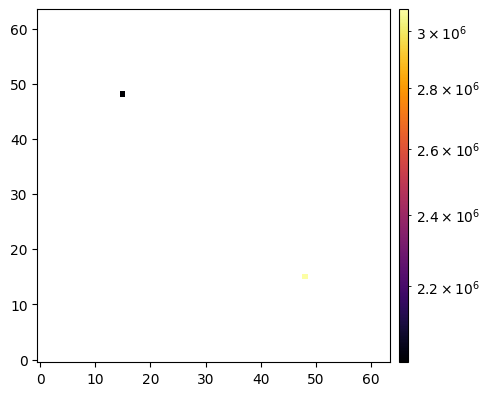

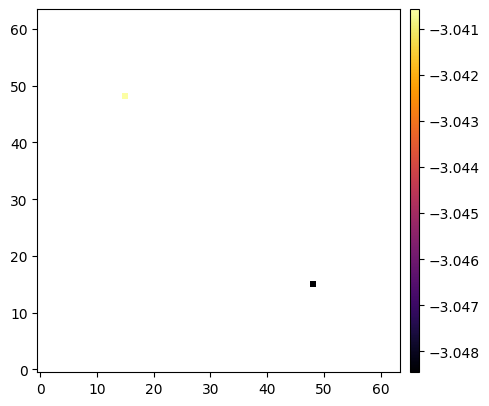

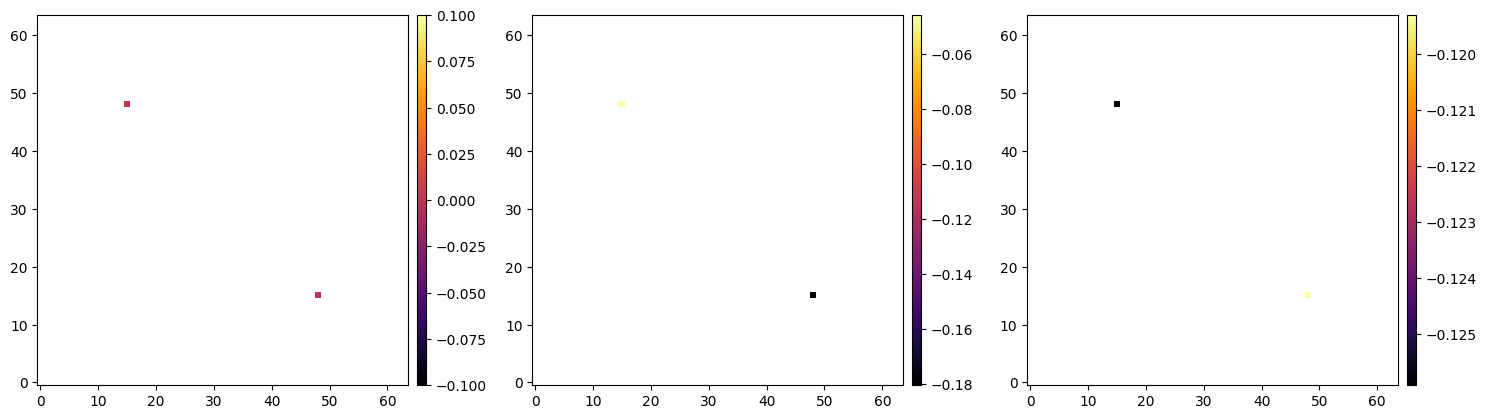

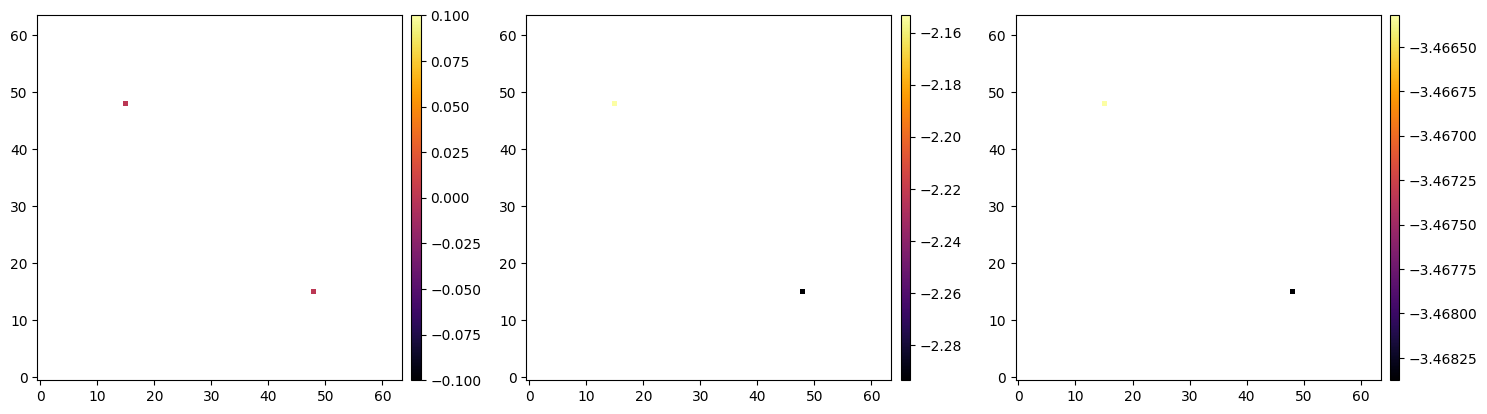

In [4]:
pm = PointModel.build(
    grid=dict(space=(32, 32)),
    point_grid=dict(coordinates=((-8.25,8.25), (8.25,-8.25)), factor=2, n_copies=2),
    freq=np.array([1e9, 2e9, 3e9]),
    params=dict(
        ref_freq_index = 0,
        i0=dict(
            mean=15,
            std=1,
        ),
        alpha=dict(
            mean=-3,
            std=0.1,
        ),
        deviations=dict(
            process='wiener',
            sigma=[0.2, 0.08],
        ),
    ),
)
print(pm.domain)

key, subkey = jax.random.split(key)
xi = pm.init(subkey)

plot_arrays(pm(xi, nans=True), norm='log', rows=1, vmax=res.max())

plot_arrays(pm.ref_freq_model(xi, nans=True), rows=1, norm='log')
plot_arrays(pm.spectral_index(xi, nans=True), rows=1)
plot_arrays(pm.spectral_deviations(xi, nans=True), rows=1)
plot_arrays(pm.spectral_model(xi, nans=True), rows=1)

Vector(
	{'tm alpha asperity': ShapeDtypeStruct(shape=(2,), dtype=float64),
	 'tm alpha flexibility': ShapeDtypeStruct(shape=(2,), dtype=float64),
	 'tm alpha fluctuations': ShapeDtypeStruct(shape=(2,), dtype=float64),
	 'tm alpha loglogavgslope': ShapeDtypeStruct(shape=(2,), dtype=float64),
	 'tm alpha mean': ShapeDtypeStruct(shape=(2,), dtype=float64),
	 'tm alpha spectrum': ShapeDtypeStruct(shape=(2, 13, 2), dtype=float64),
	 'tm alpha xi': ShapeDtypeStruct(shape=(2, 8, 8), dtype=float64),
	 'tm dev sigma': ShapeDtypeStruct(shape=(2,), dtype=float64),
	 'tm dev xi': ShapeDtypeStruct(shape=(2, 2, 8, 8), dtype=float64),
	 'tm i0 asperity': ShapeDtypeStruct(shape=(2,), dtype=float64),
	 'tm i0 flexibility': ShapeDtypeStruct(shape=(2,), dtype=float64),
	 'tm i0 fluctuations': ShapeDtypeStruct(shape=(2,), dtype=float64),
	 'tm i0 loglogavgslope': ShapeDtypeStruct(shape=(2,), dtype=float64),
	 'tm i0 spectrum': ShapeDtypeStruct(shape=(2, 13, 2), dtype=float64),
	 'tm i0 xi': ShapeDtypeStr

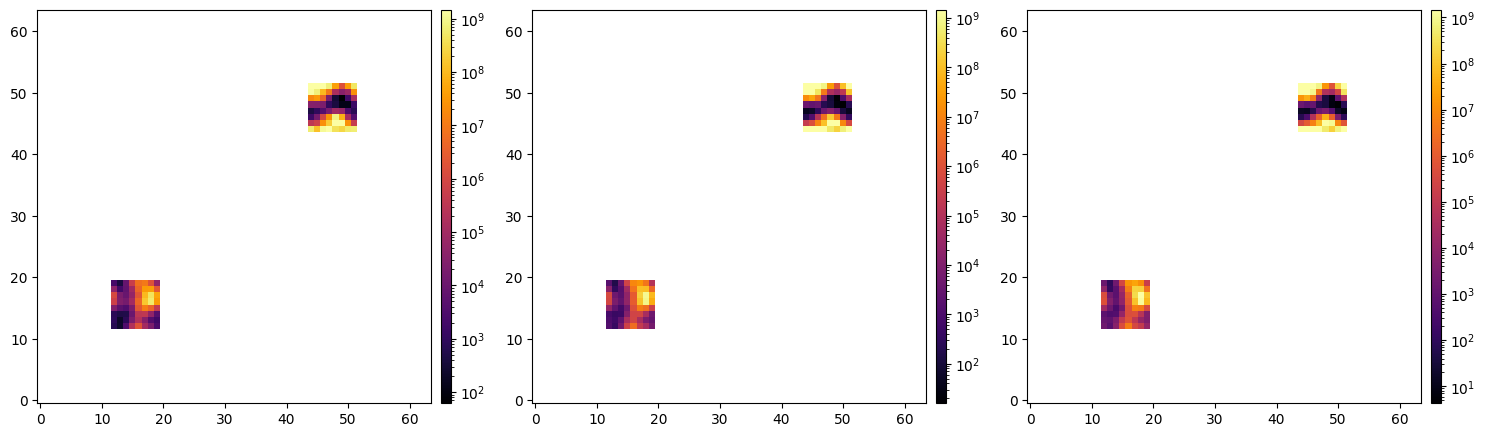

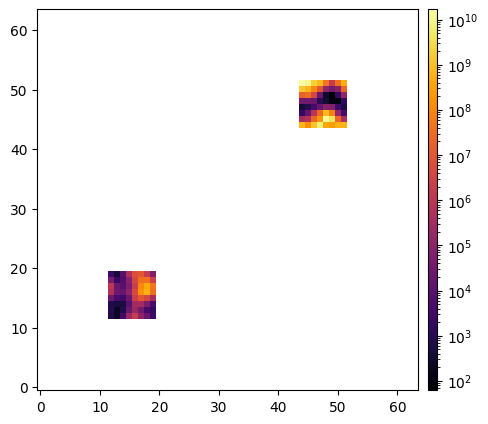

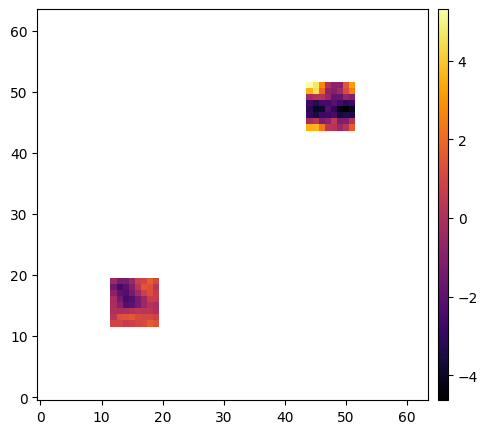

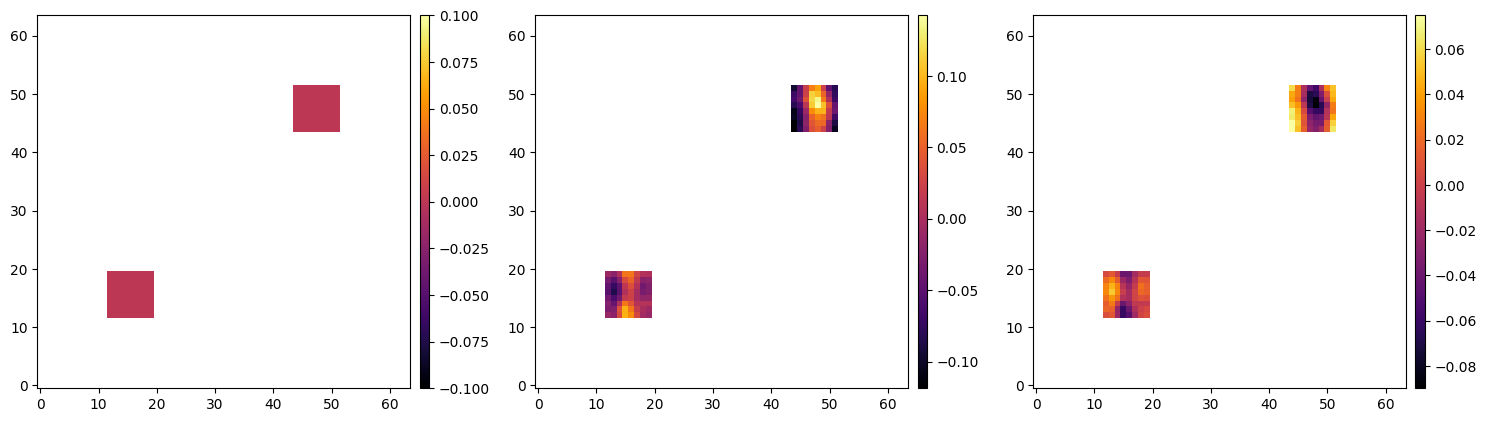

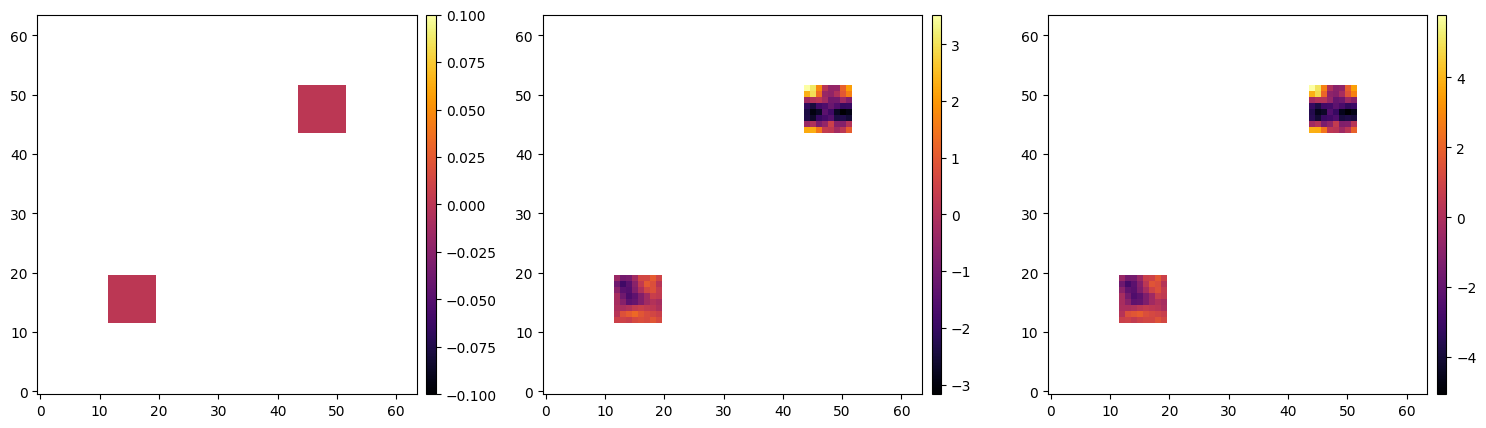

In [5]:
tm = TileModel.build(
    grid=dict(space=(32, 32)),
    tile_grid=dict(space=(4,4), center=((-8,-8), (8,8)), factor=2, n_copies=2),
    freq=np.array([1e9, 2e9, 3e9]),
    params=dict(
        ref_freq_index = 0,
        zero_mode=[3, 1],
        spatial_amplitude=dict(
            fluctuations=[5, 1],
            loglogavgslope=[-2, 0.5],
            flexibility=[1.2, 0.4],
            asperity=[0.2, 0.2],
        ),
        spectral_index=dict(
            mean=[-1, 0.5],
            fluctuations=[3, 1],
        ),
        spectral_amplitude=dict(
            loglogavgslope=[-2, 0.5],
            flexibility=[1.2, 0.4],
            asperity=[0.2, 0.2],
        ),
        deviations=dict(
            process='wiener',
            sigma=[0.2, 0.08],
        ),
    ),
    offset=10,
)
print(tm.domain)

key, subkey = jax.random.split(key)
xi = tm.init(subkey)

plot_arrays(tm(xi, nans=True), norm='log', rows=1, vmax=res.max())

plot_arrays(tm.ref_freq_model(xi, nans=True), rows=1, norm='log')
plot_arrays(tm.spectral_index(xi, nans=True), rows=1)
plot_arrays(tm.spectral_deviations(xi, nans=True), rows=1)
plot_arrays(tm.spectral_model(xi, nans=True), rows=1)

ComponentModel(
	<bound method ComponentModel.__call__>,
	domain=Vector(
		{'bg alpha asperity': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
		 'bg alpha flexibility': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
		 'bg alpha fluctuations': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
		 'bg alpha loglogavgslope': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
		 'bg alpha mean': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
		 'bg alpha spectrum': ShapeWithDtype(shape=(133, 2), dtype=<class 'numpy.float64'>),
		 'bg alpha xi': ShapeWithDtype(shape=(32, 32), dtype=<class 'numpy.float64'>),
		 'bg dev sigma': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
		 'bg dev xi': ShapeWithDtype(shape=(2, 32, 32), dtype=<class 'numpy.float64'>),
		 'bg i0 asperity': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
		 'bg i0 flexibility': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
		 'bg i0 fluctuations': Sha

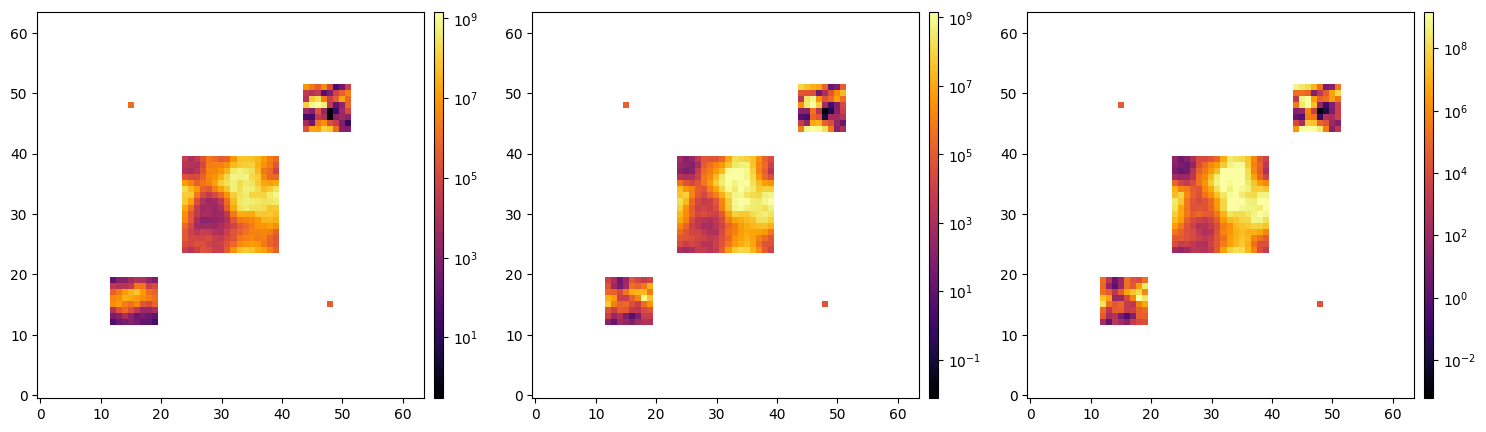

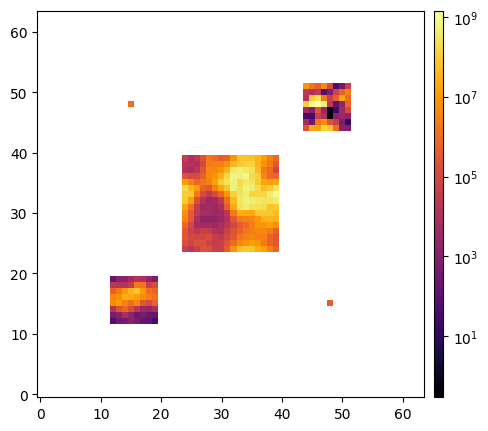

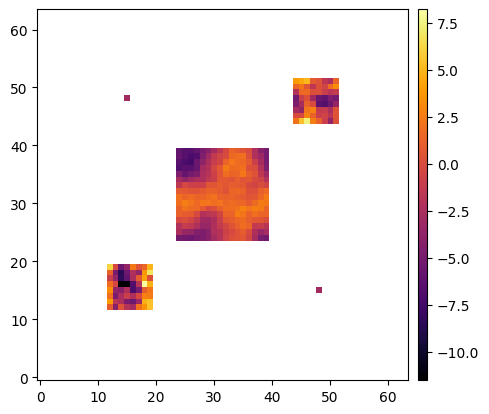

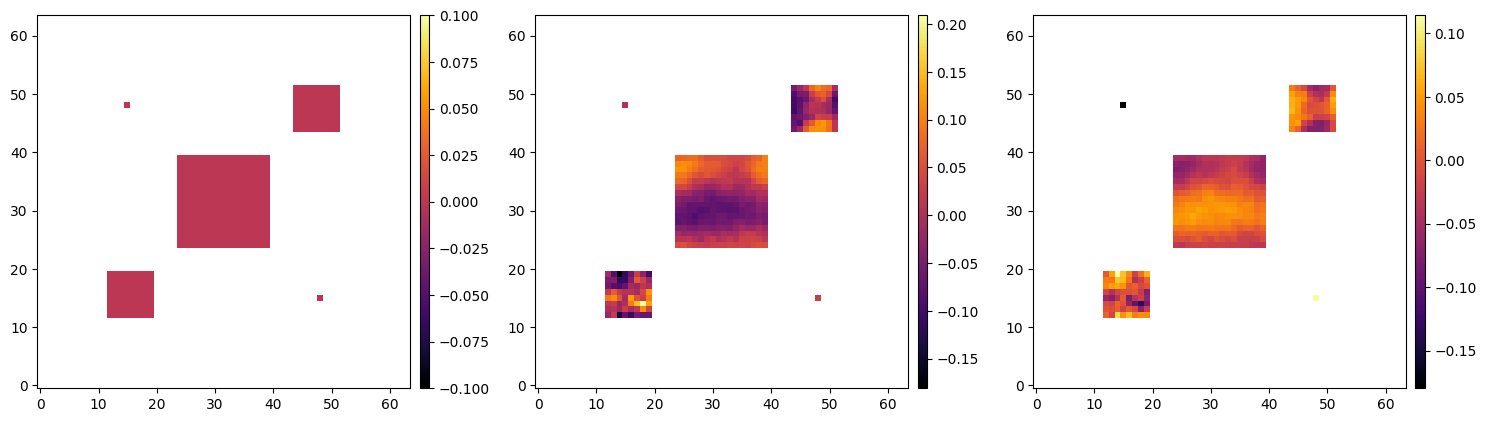

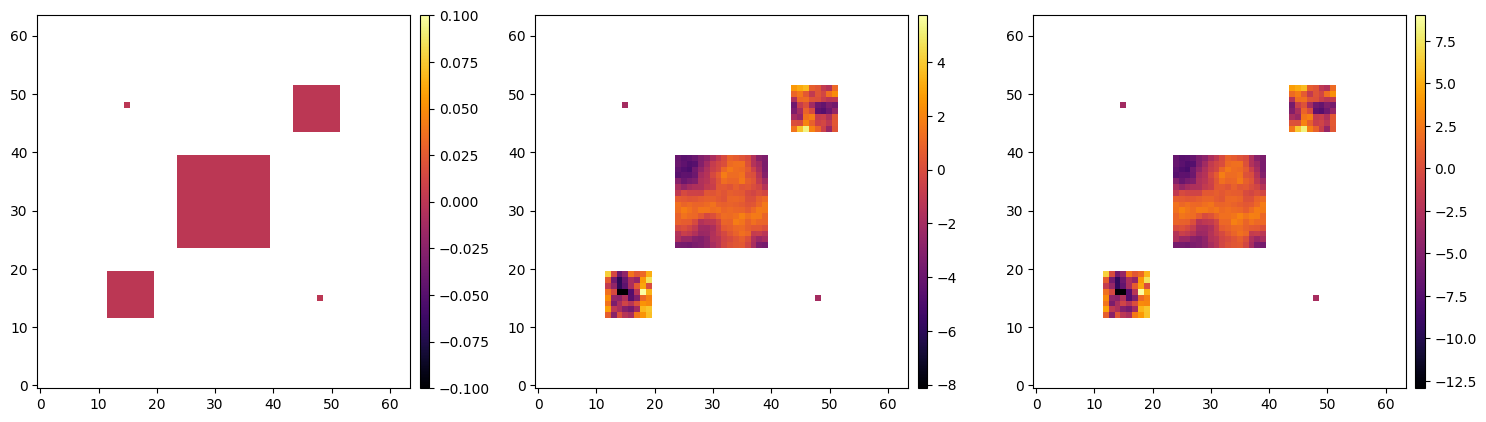

In [6]:
cm = ComponentModel.build(
    background=bg,
    object=oj,
    points=pm,
    tiles=tm,
)
print(cm)

key, subkey = jax.random.split(key)
xi = cm.init(subkey)

plot_arrays(cm.points_and_objects(xi, nans=True), norm='log', rows=1, vmax=res.max())

plot_arrays(cm.points_and_objects.ref_freq_model(xi, nans=True), rows=1, norm='log')
plot_arrays(cm.points_and_objects.spectral_index(xi, nans=True), rows=1)
plot_arrays(cm.points_and_objects.spectral_deviations(xi, nans=True), rows=1)
plot_arrays(cm.points_and_objects.spectral_model(xi, nans=True), rows=1)

ComponentModel(
	<bound method ComponentModel.__call__>,
	domain=Vector(
		{'bg alpha asperity': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
		 'bg alpha flexibility': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
		 'bg alpha fluctuations': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
		 'bg alpha loglogavgslope': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
		 'bg alpha mean': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
		 'bg alpha spectrum': ShapeWithDtype(shape=(133, 2), dtype=<class 'numpy.float64'>),
		 'bg alpha xi': ShapeWithDtype(shape=(32, 32), dtype=<class 'numpy.float64'>),
		 'bg dev sigma': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
		 'bg dev xi': ShapeWithDtype(shape=(2, 32, 32), dtype=<class 'numpy.float64'>),
		 'bg i0 asperity': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
		 'bg i0 flexibility': ShapeWithDtype(shape=(), dtype=<class 'numpy.float64'>),
		 'bg i0 fluctuations': Sha

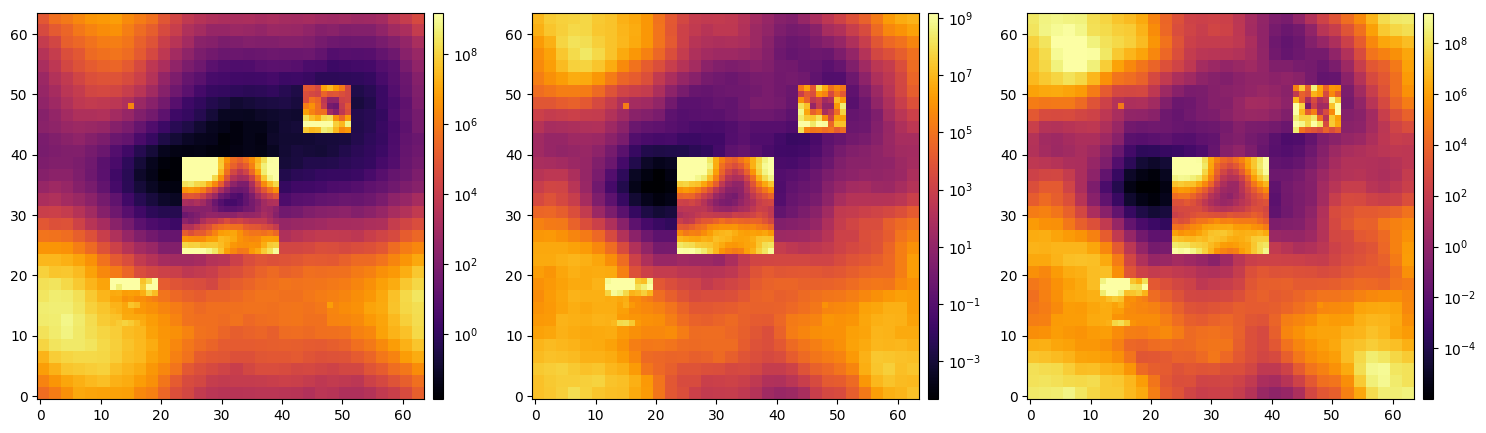

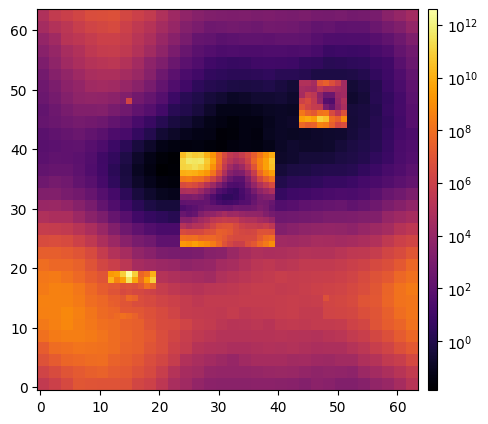

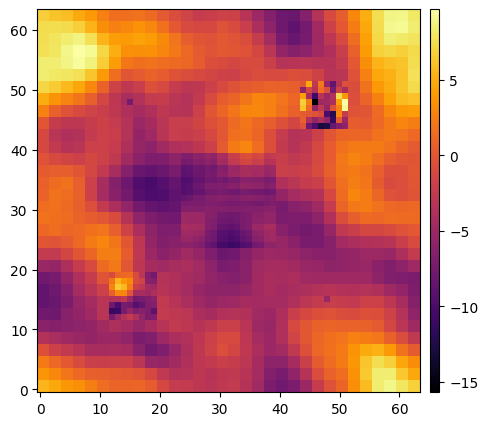

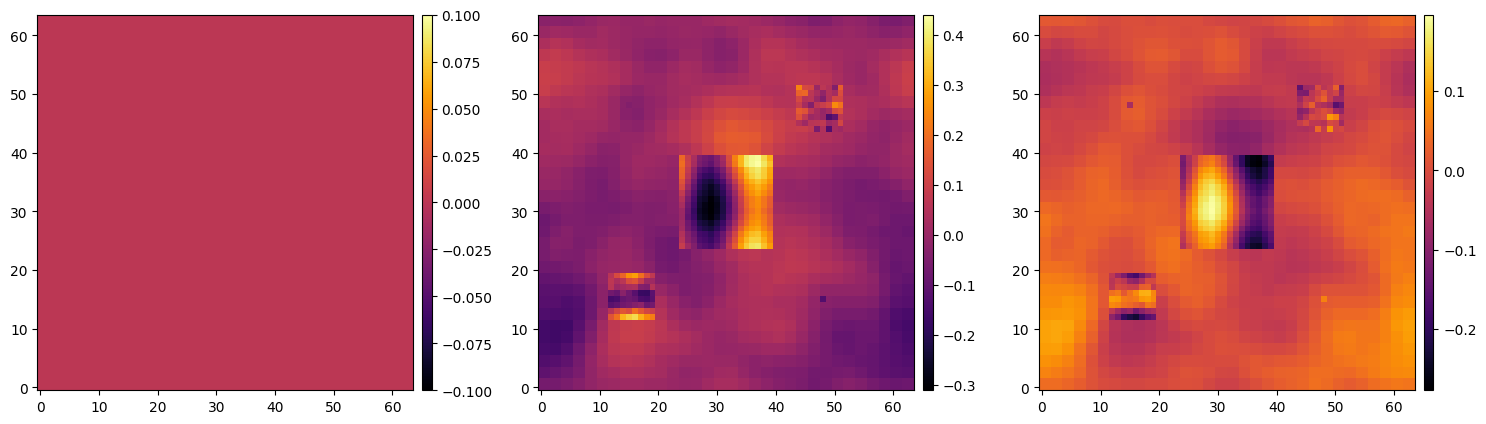

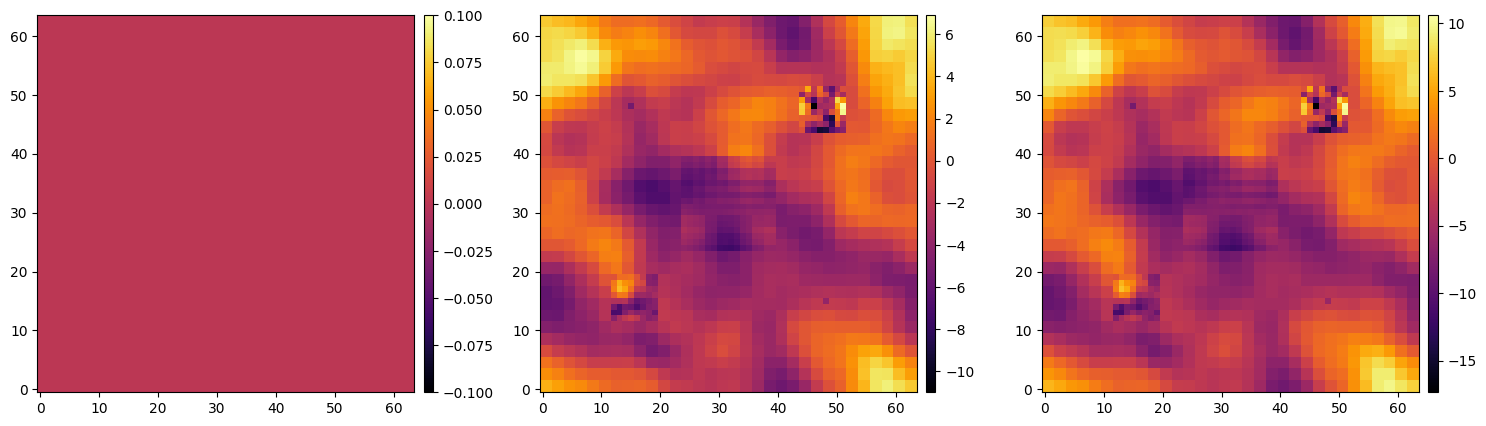

In [7]:
cm = ComponentModel.build(
    background=bg,
    object=oj,
    points=pm,
    tiles=tm,
)
print(cm)

key, subkey = jax.random.split(key)
xi = cm.init(subkey)

plot_arrays(cm(xi), norm='log', rows=1, vmax=res.max())

plot_arrays(cm.ref_freq_model(xi), rows=1, norm='log')
plot_arrays(cm.spectral_index(xi), rows=1)
plot_arrays(cm.spectral_deviations(xi), rows=1)
plot_arrays(cm.spectral_model(xi), rows=1)